# Лабораторная работа №4 — Линейные модели, SVM и дерево решений

## Цель
Сравнить три класса моделей на задаче бинарной классификации Titanic и проанализировать дерево решений.


In [1]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, f1_score

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')

dataset_path = PROJECT_ROOT / 'courses_current' / 'notebooks' / 'features' / 'data' / 'titanic.csv'
df = pd.read_csv(dataset_path)
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
y = df['Survived']


In [2]:
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
cat_cols = ['Sex', 'Embarked']

prep = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
}


## 1. Обучение и сравнение моделей


In [3]:
rows = []
fitted_tree_pipe = None
for name, model in models.items():
    pipe = Pipeline([('prep', prep), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    })
    if name == 'DecisionTree':
        fitted_tree_pipe = pipe

res = pd.DataFrame(rows).sort_values('f1', ascending=False)
display(res)


,model,accuracy,f1
1,SVM (RBF),0.793722,0.712500
0,LogisticRegression,0.771300,0.698225
2,DecisionTree,0.771300,0.657718


## 2. Важность признаков в дереве решений


,importance
cat__Sex_female,0.538835
num__Pclass,0.169366
num__Age,0.139750
num__Fare,0.128762
num__SibSp,0.022510
num__Parch,0.000777
cat__Sex_male,0.000000
cat__Embarked_C,0.000000
cat__Embarked_Q,0.000000
cat__Embarked_S,0.000000


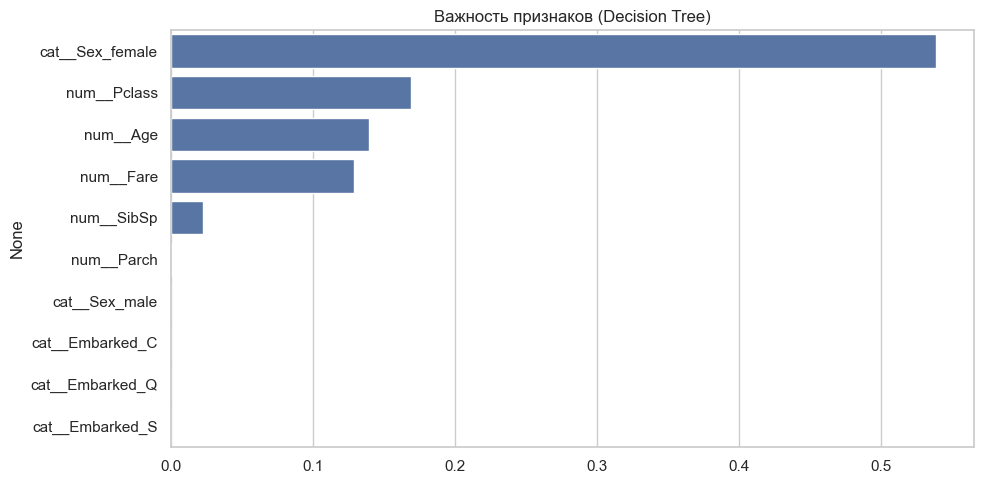

<Figure size 640x480 with 0 Axes>

In [4]:
feature_names = list(fitted_tree_pipe.named_steps['prep'].get_feature_names_out())
tree_model = fitted_tree_pipe.named_steps['model']
importance = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)

display(importance.to_frame('importance'))

plt.figure(figsize=(10,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title('Важность признаков (Decision Tree)')
plt.tight_layout()
plt.show()
plt.savefig(ART / 'tree_feature_importance.png', dpi=170, bbox_inches='tight')


## 3. Правила дерева решений


In [5]:
rules = export_text(tree_model, feature_names=feature_names)
print(rules[:3000])
(ART / 'tree_rules.txt').write_text(rules, encoding='utf-8')

res.to_json(ART / 'metrics.json', orient='records', force_ascii=False, indent=2)


|--- cat__Sex_female <= 0.50
|   |--- num__Age <= -2.03
|   |   |--- num__SibSp <= 2.04
|   |   |   |--- class: 1
|   |   |--- num__SibSp >  2.04
|   |   |   |--- num__Age <= -2.10
|   |   |   |   |--- class: 0
|   |   |   |--- num__Age >  -2.10
|   |   |   |   |--- class: 1
|   |--- num__Age >  -2.03
|   |   |--- num__Pclass <= -0.98
|   |   |   |--- num__Fare <= -0.11
|   |   |   |   |--- class: 0
|   |   |   |--- num__Fare >  -0.11
|   |   |   |   |--- num__Fare <= -0.01
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__Fare >  -0.01
|   |   |   |   |   |--- class: 0
|   |   |--- num__Pclass >  -0.98
|   |   |   |--- num__Fare <= 0.36
|   |   |   |   |--- num__Fare <= -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__Fare >  -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__Fare >  0.36
|   |   |   |   |--- num__Fare <= 0.67
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__Fare >  0.67
|   |   |   |   |   |--- class: 0
|--- cat__Sex_f

## Выводы
- SVM и логистическая регрессия показывают стабильное качество.
- Дерево решений дает интерпретируемые правила и важности признаков.
